# Geog 356T Spatial Data Science and Maps
### Prof. Yuhao Kang (yuhao.kang@austin.utexas.edu)
### TA: Brody Manquen (bwm866@my.utexas.edu)

# Lab 10 - Generative AI in Geography & Cartography

# *Please use Google Colab for this lab*

### This lab introduces some recent uses of generative artificial intelligence (GenAI) for two geographic tasks.

#### First, you will learn how to use the OpenAI Python package to query ChatGPT with a series of prompts designed to capture the place identities of a city. Place identity formation is a common subject of human geographic research.

#### Second, you will learn how to transfer art styles from a non-map image to a map. Although we don't use GenAI to create entire maps (given the computational complexity), we can use GenAI to pull style elements from an image and apply them to existing maps.


In [ ]:
!pip install openai

In [ ]:
from openai import OpenAI
import pandas as pd
import time
import json
import csv
import os
from datetime import datetime

# Section 1: City Place Identity via ChatGPT Prompts

We will be reproducing some of the method used in this *Nature* article co-authored by Dr. Kang: https://www.nature.com/articles/s41599-024-03645-7

In this article, they assess the accuracy of ChatGPT's characterization of place identities, defined as “sub-structure of the self-identity of the person consisting of broadly conceived cognitions about the physical world in which the individual lives” (Proshansky et al. 1983) compared to other characterizations of place on the internet, namely Wikipedia. Large language models (LLMs) are trained on copious amounts of data, including on texts referring to individual cities and their place characteristics. The researchers find that LLMs like ChatGPT can accurately describe the distinguishing features of a city's place identity.

### Below, we will re-use some of this article's code to introduce prompting ChatGPT within a Python environment.



In [ ]:
# Set up the OpenAI API client
## this is a class access key for our lab work. It tells ChatGPT who we are and lets us communicate with ChatGPT over Python.
client = OpenAI(api_key="") ## ENTER YOUR OPENAI API HERE!

In [ ]:
# initialize a list of cities
global_cities = ['Austin', 'Dallas', 'Houston', 'San Antonio', 'London', 'New York City', 'Chicago', 'Tokyo', 'Paris', 'Mumbai', 'São Paulo', 'Shanghai', 'Rome','Beiruit', 'Lagos']
global_cities = ["Austin"]

In [ ]:
# Set up the model - we'll use a simpler version of the current GPT-5 model
MODEL_NAME = "gpt-5-mini"

# Settings -- leave default for now
MAX_TOKENS = 2048 # tokens are the 'chunks' of output. A lower MAX_TOKENS will force the model to output smaller results.

In [ ]:
# Set up the prompts

# the Python here is noteable:
  # %s is a placeholder. we are telling Python to replace this position with an item from the city list
  # for city in global_cities iterates through the global_cities list
    # %(city) tells our code to replace %s with the current iteration of city in the global_cities list
  # each iteration through the city list adds a new value to our prompt lists
    # so, our resulting prompt lists are a series of prompts where each city is slotted into our placeholder

place_identity_prompts = ['What is the place identity of %s? Give it to me in ten bullet points.' %(city) for city in global_cities]
urban_identity_prompts = ['What is the urban identity of %s? Give it to me in ten bullet points.' %(city) for city in global_cities]
street_identity_prompts = ['What is the place identity of streetscapes in %s? Give it to me in a brief paragraph.' %(city) for city in global_cities]

In [ ]:
# peek into one of the prompts lits
place_identity_prompts[0:5]

['What is the place identity of Austin? Give it to me in ten bullet points.']

In [ ]:
# empty lists to save responses
place_identity_responses = []
urban_identity_responses = []
street_identity_responses = []

In [ ]:
# System prompt defines behavior of GPT.

# commonly, we tell ChatGPT that they are a certain profession or have a specific skill to focus the model on answering like someone specifically knowledgeable on the topic.

PROMPT_SYSTEM = "You are a human geography tutor who has studied place-based identity formation."


In [ ]:
# core documentation for this workflow: https://platform.openai.com/docs/api-reference/chat/create

## NOTE: THIS MAY TAKE 10-15 MINUTES TO RUN

for i in range((len(global_cities))):

    print(f"Processing city {i+1} of {len(place_identity_prompts)}...")

    #client.chat.completions.create() --  this creates a new chat with ChatGPT

    # place identity
    place_result = client.chat.completions.create(
        model=MODEL_NAME,
        max_completion_tokens=MAX_TOKENS,
        messages=[
            {"role": "system", "content": PROMPT_SYSTEM},
            {"role": "user", "content": place_identity_prompts[i]}
        ]
    )
    place_identity_responses.append(place_result.choices[0].message.content)

    # urban identity
    urban_result = client.chat.completions.create(
        model=MODEL_NAME,
        max_completion_tokens=MAX_TOKENS,
        messages=[
            {"role": "system", "content": PROMPT_SYSTEM},
            {"role": "user", "content": urban_identity_prompts[i]}
        ]
    )
    urban_identity_responses.append(urban_result.choices[0].message.content)

    # street identity
    street_result = client.chat.completions.create(
        model=MODEL_NAME,
        max_completion_tokens=MAX_TOKENS,
        messages=[
            {"role": "system", "content": PROMPT_SYSTEM},
            {"role": "user", "content": street_identity_prompts[i]}
        ]
    )
    street_identity_responses.append(street_result.choices[0].message.content)

Processing city 1 of 1...


In [ ]:
# Put results into a table

# in Colab, on the righthand side of the table, select the top icon "Convert this dataframe to an interactive table" -- it'll help you read the responses
cities_gpt_results = pd.DataFrame({
    "City": global_cities,
    "Place Identity Prompt": place_identity_prompts,
    "Place Identity Response": place_identity_responses,
    "Urban Identity Prompt": urban_identity_prompts,
    "Urban Identity Response": urban_identity_responses,
    "Street Identity Prompt": street_identity_prompts,
    "Street Identity Response": street_identity_responses
})

cities_gpt_results

# Exercise 1

Choose 5 cities to work with -- these can either be from the `global_cities` list, or 5 cities of interest to you. They should be relatively large (~1 million) to ensure that they're well-represented by ChatGPT's training material.

## Part 1

1. Keeping the same settings as the example, run the script and save the dataframe to a unique variable. This is our baseline.

2. Rerun the script using a new variable `PROMPT_SYSTEM2` as input:

    PROMPT_SYSTEM2 = "You are a physical geography tutor who has studied the human-environment relationships that have shaped urban identity."

How drastically do the results differ from the original prompt by only changing the system prompt (i.e., not your actual prompt questions)? Glance at the Wikipedia for a few of your cities -- are these results roughly accurate, based on your understanding?

## Part 2

Design a prompt set (system prompt + 1-2 question prompts) on a geographic research area that you are familiar with (e.g., urban geography, physical geography, human geography -- and any subspecialty within). These prompts should be relatively generic, meaning that they should not be tailored to one specific research site, but generalized for that subfield of geography (much like the example prompts).

Apply these prompts to a few (3-5) locations of interest -- this could be cities or regions, whatever works best for your research area.

Save and print the results as a dataframe. Answer the following questions:

- How & why did you choose your prompt wording?
- How well do the results match your expectations? Do they appear generally accurate, or not?

# Section 2: Map Style Transfer



Section 2 will guide you through a method for transferring stylistic elements of an image to a useable 'map style' in Mapbox (a platform to host webmaps -- if you look at the bottom corners of webmaps across the internet, you'll often see the "Mapbox" logo).

This is based on the work of the GISense Lab here at UT: https://github.com/GISense/CartoAgent

There are essentially two components for this lab:
  - input image: ChatGPT will assess the colors and themes of an image
  - input map style: a generic style sheet that displays an urban map. This tells Mapbox how you want roads, rivers, labels, etc. to be displayed (colors, widths, etc.)

Using ChatGPT prompts, we will analyze these two inputs, then ask ChatGPT to transfer the key visual elements of the input image onto the map style. The end result, therefore, will be a map of Austin that looks like our input image **and** is fully useable in Mapbox.

Visually, we will take this input Mapbox style:



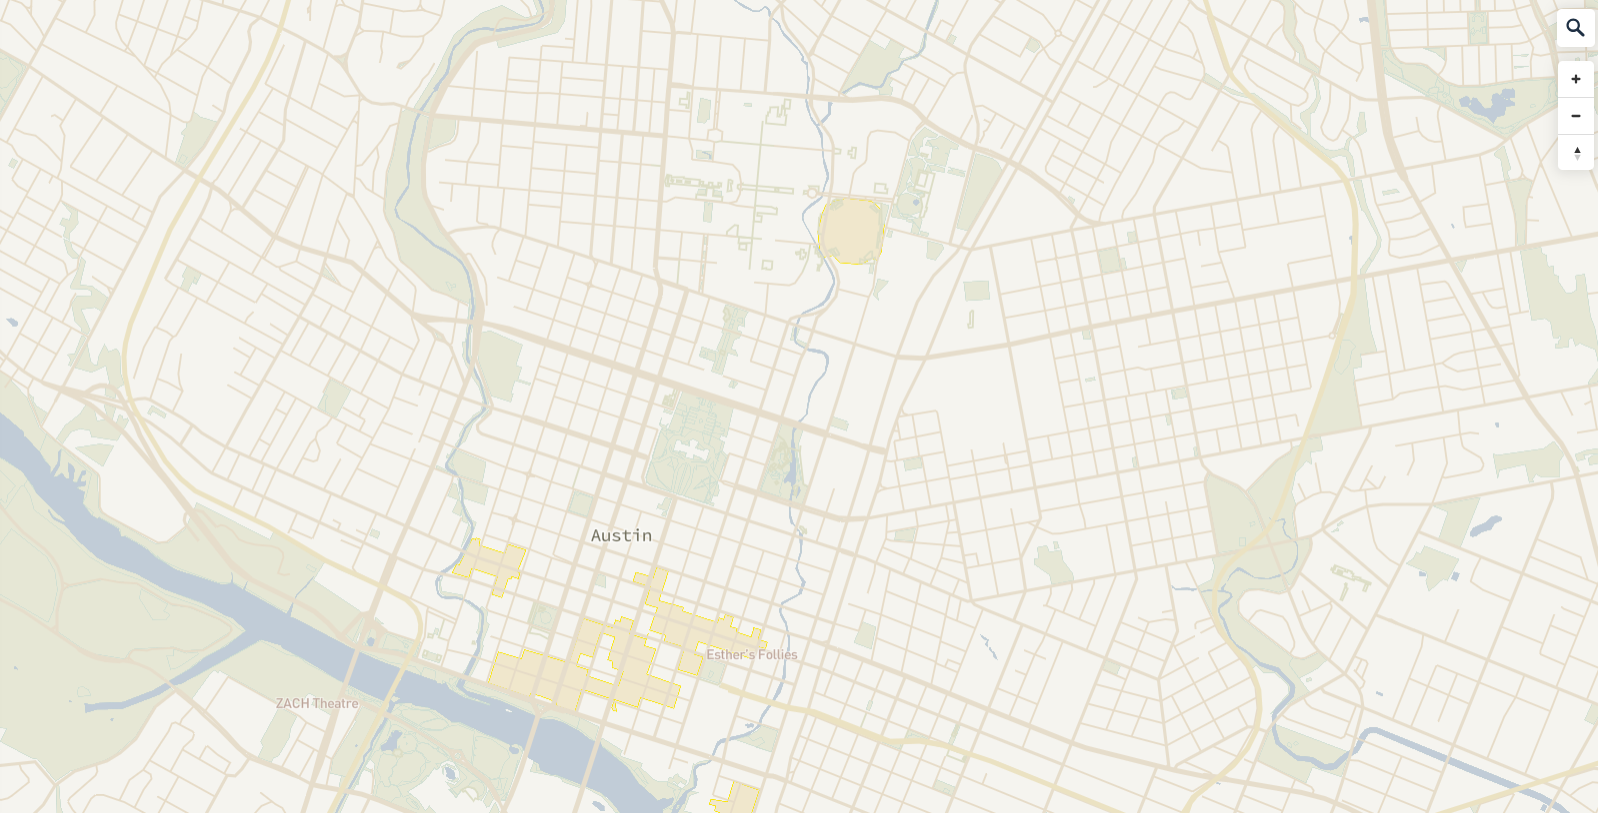

And convert it like this:

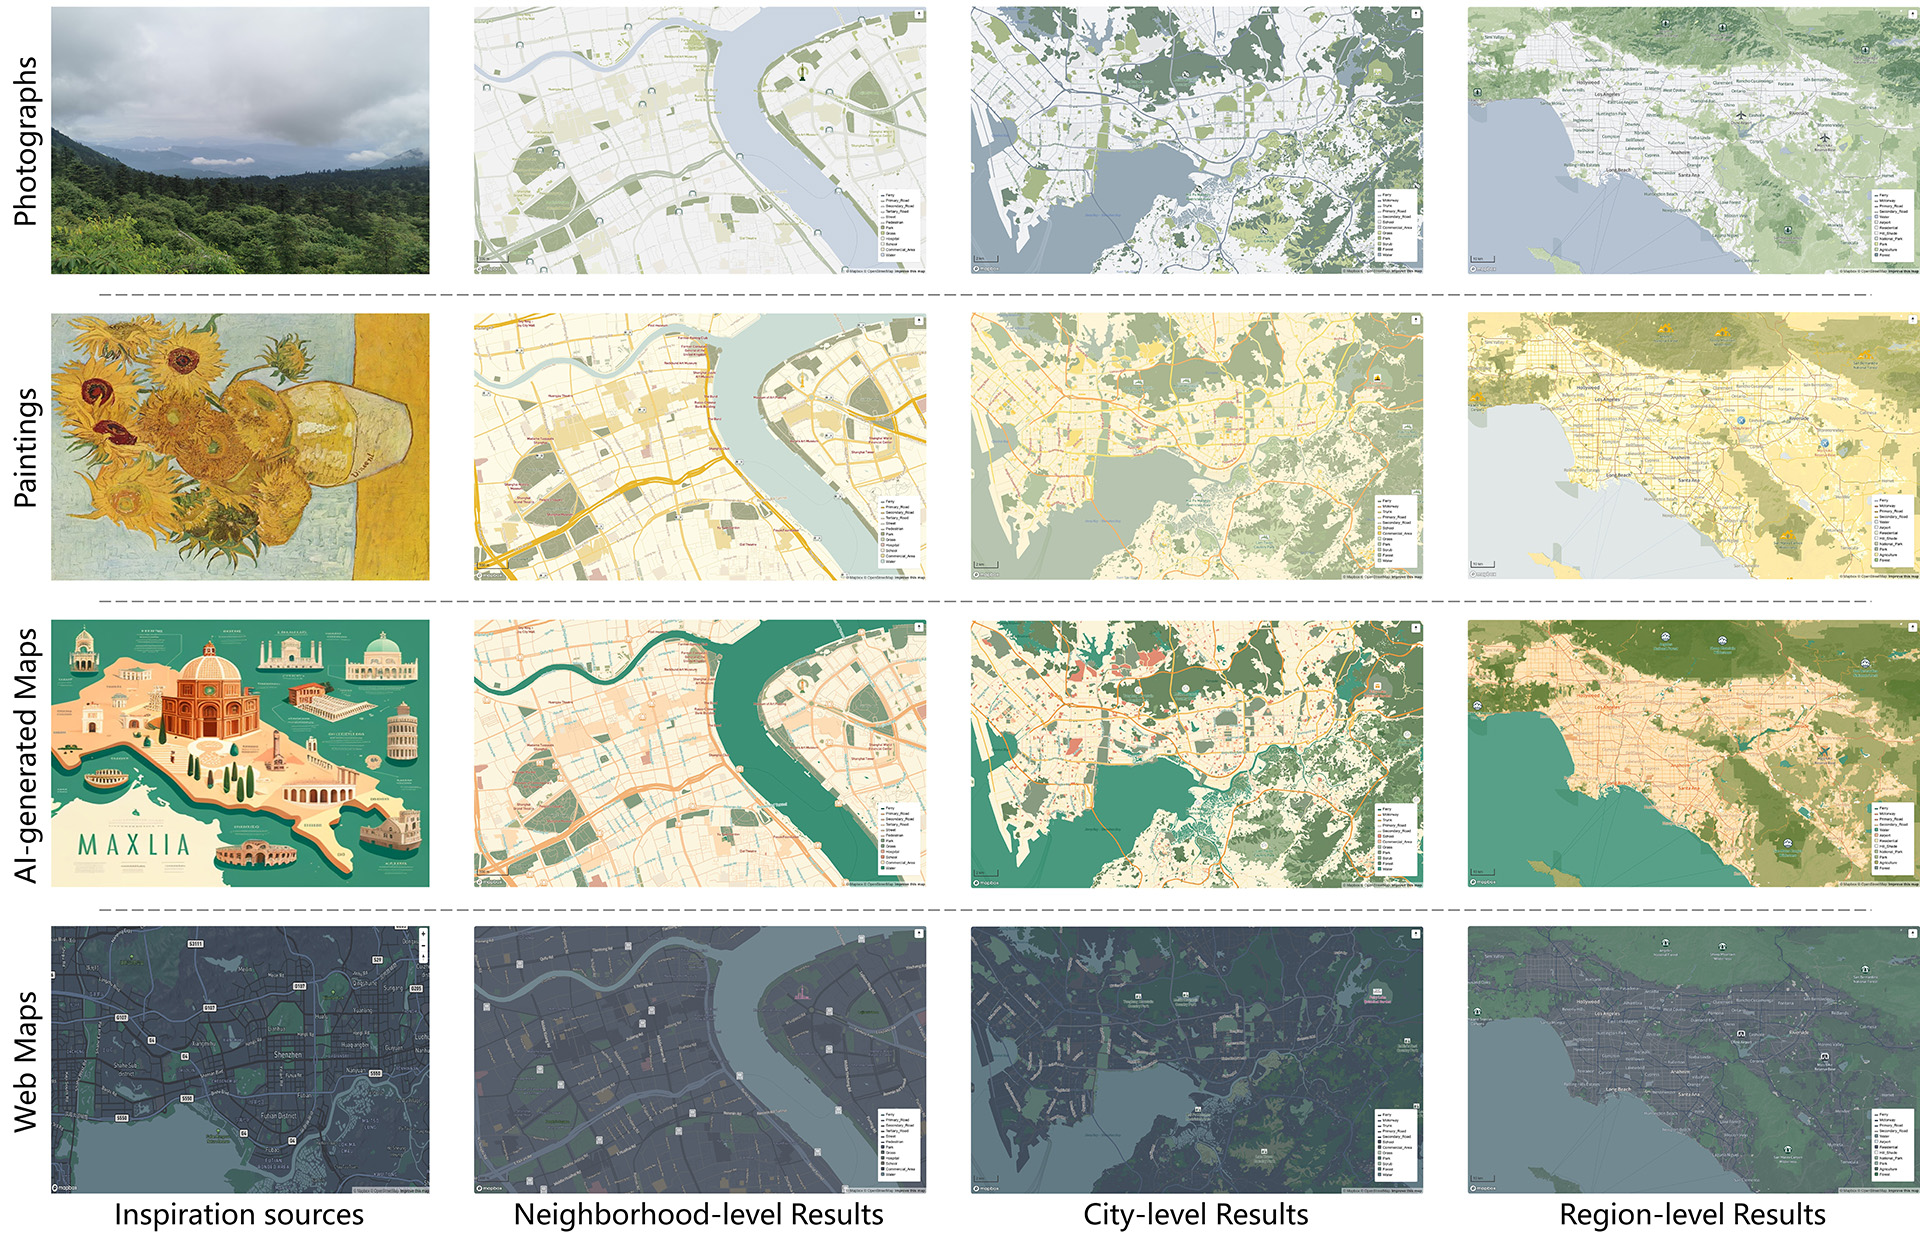

Before we get started, we'll need a Mapbox account. Follow this link: https://www.mapbox.com/

You should be able to sign up for a Mapbox account with your UT email **for free**. You may need to add credit card information but you shouldn't need to pay.

Once you get set this up, go to the Console (or follow this link: https://console.mapbox.com/)

On the righthand side of this page, you can find your API token. Copy and paste it in the empty string below.

In [ ]:
mapbox_api = '' # Your MapBox API here!

Now we can install the packages as usual, and reset our OpenAI API just in case.

In [ ]:
!pip install mapboxgl

In [ ]:
from openai import OpenAI
import json
from mapboxgl.viz import MapViz

In [ ]:
client = OpenAI(api_key="") # Your OpenAI API here!

Set the path to our inspiraton image. This is in your `data` folder.

Upload the contents from that folder into Colab and copy the path of `inspiration.jpg` into the string below (it may be different from "/content/inspiration.jpg")

In [ ]:
inspiration = "/content/inspiration.jpg"          # The image representing the visual style

In [ ]:
from IPython.display import Image #Image function lets us process imagery within Python
Image(filename=inspiration)

### Image Appreciator

In [ ]:
import base64

# we need to read the inspiration.jpg with base64 encoding so that we can upload it to ChatGPT.
with open(inspiration, "rb") as img_file:
    inspiration_b64 = base64.b64encode(img_file.read()).decode("utf-8")

Now let us start inputting prompts. For this part of the lab, we are giving you the prompts developed by the GISense lab, as they are quite long and specially tailored to this task.

However, please do read through them to understand what you are asking of the LLM. Try to get a feel for the language and level of detail needed for our task.

First, we want ChatGPT to read our image:

In [ ]:
prompt_1 = """
I want you to act as an image appreciator. I will provide you with an image. Your task is to describe it as detailed as possible, which means that the following topics should be covered:
•       Content: What is in the image? What are the attributes and relationships of these things? What objects cannot possibly appear in this image? What temporal and spatial information does the image reflect?
•       Color: What is the color of objects and background? Please provide hexadecimal color values as accurately as possible, e.g. #000000. What effect does the combination of these colors give to the brightness and contrast of the image?
•       Theme & Design: If the provided image is a painting, then what is the theme of the painting? (e.g. Realistic, Surreal) What are the characteristics of the design? (e.g. Simple, Detailed, Complex)
If you understand the requirements of this task, you can reply 'OK' and provide your description after I provide the image.
"""

# Send the prompt with the attached image using base64 encoded data
response_1 = client.chat.completions.create(  #this string of functions & methods essentially creates a new "chat" with ChatGPT
    model="gpt-5",
    messages=[
        {"role": "system", "content": "You are an image appreciation expert."}, #system prompt
        {"role": "user", "content": prompt_1}, # prompt one
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Here is the reference image:"},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{inspiration_b64}" ## CRUCIAL: feeds our image into ChatGPT (note the data:image/jpeg)
                    }
                }
            ]
        }
    ]
)

image_description = response_1.choices[0].message.content
print("=== Image Appreciation Result ===\n")
print(image_description)

### Style Sheet Design

This will format your image input's elements as style sheet elements. This is as an **intermediary** step between our input image and our final style sheet.


In [ ]:
prompt_2 = """
I want you to act as a style sheet designer. I will provide you with a reference image and its description, covering the content, color, theme & design. Your task is to design a suitable style sheet to render the following map elements so that the style of the rendered map is as consistent as possible with the reference image:
[Data name]: UT Campus;
[Map elements]:
• background elements: Background.
• fill elements: Commercial_area, Green_space, Water, Commercial_building, Residential_building.
• line elements: Walkway, Street, Tertiary_road, Secondary_road, Primary_road, Metro.
• symbol_label elements: Water_label, Settlement_label, Street_label, Tertiary_road_label, Secondary_road_label, Primary_road_label, Natural_landscape_label, Cultural_landscape_label.
• symbol_icon elements: Metro_station, Oriental_pearl_tower.
[Requirements]:
In the process of designing the style sheet, you can perform different actions for different types of elements:
• For each background element, you can set the background-color.
• For each fill element, you can set the fill-outline-color, fill-opacity, fill-color.
• For each line element, you can set the line-color, line-width, line-opacity.
• For each symbol_label element, you can set the text-halo-width, text-halo-color, text-color, text-halo-blur.
• For each symbol_icon element, you can describe the expected style as detailed as possible, e.g. its content, color, theme & design. The icon designer will design this icon according to your expectations.
Meanwhile, please pay attention to the following requirements:
1. Completeness: please set the styles for all elements;
2. Unity: the styles of relevant elements should be as close as possible, such as roads of different levels, and when choosing a style, please consider the contrast and visual hierarchy of the map as much as possible;
3. Rationality: when choosing a style, it is necessary to take into account the semantic information of the elements, that is, the real-world connotations of the elements;
4. Explainability: please explain the specific reason for your rendering;
5. Normativeness: all colors should be given in hexadecimal format, e.g. #000000, and opacity should be a decimal between 0 and 1, where 0 represents transparent and 1 represents opaque. Please strictly follow the following JSON format to return results and just return this JSON file:
{
    "background": {
        "Background": {"background-color": ..., },
    },
    "fill": {
        "Commercial_area": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
        "Green_space": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
        "Water": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
        "Commercial_building": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
        "Residential_building": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
    },
    "line": {
        "Walkway": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
        "Street": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
        "Tertiary_road": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
        "Secondary_road": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
        "Primary_road": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
        "Metro": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
    },
    "symbol_label": {
        "Water_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        "Settlement_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        "Street_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        "Tertiary_road_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        "Secondary_road_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        "Primary_road_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        "Natural_landscape_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        "Cultural_landscape_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
    },
    "symbol_icon": {
        "Metro_station": {"expectation": ..., "explanation": ...},
        "Oriental_pearl_tower": {"expectation": ..., "explanation": ...},
    },
}
If you understand the requirements of this task, you can reply 'OK' and provide your answer after I provide the reference image and its description.
"""

response_2 = client.chat.completions.create(
    model="gpt-5",
    messages=[
        {"role": "system", "content": "You are a Mapbox style sheet designer."},
        {"role": "user", "content": prompt_2},
        {"role": "user", "content": f"Reference image description:\n{image_description}"}
    ],
)

new_style_json = response_2.choices[0].message.content

# Save output for next step
with open("generated_style.json", "w") as f:
    f.write(new_style_json)

print("=== New Map Style Sheet (JSON) ===\n")
print(new_style_json[:1000], "\n...truncated...")

### File Configuration

This will take our style sheet elements from Prompt 2 and input them into the whole, final style sheet.

In [ ]:
style_sheet = "/content/neighborhood_style.json"  # The base Mapbox style to be modified
with open(style_sheet, "r") as f:
    base_style = f.read()

prompt_3 = """
I want you to act as a senior computer expert. I will provide you with a style specification file and a new style sheet.
Your task is to modify the style specification file based on the new style sheet while strictly following the original style specification file format.
Please note that the returned result should be the entire modified style specification file, including the unmodified parts.
Also, when encountering a filtering expression, please refrain from modifying the filtering condition and only modify the variable value.
For example, when you come across the expression: "opacity": ["match",["get","class"],["commercial_area"],1,0] and you want to change its opacity to 0.8, you should understand that the aforementioned expression selects features in the layer with a class of "commercial_area" and sets their opacity to 1, while setting the opacity of others to 0.
Therefore, you should modify the expression to "opacity": ["match",["get","class"],["commercial_area"],0.8,0].
Provide the modified style specification file after I provide the original style specification file and the new style sheet.
"""

response_3 = client.chat.completions.create(
    model="gpt-5",
    messages=[
        {"role": "system", "content": "You are a Mapbox style configuration expert."},
        {"role": "user", "content": prompt_3},
        {"role": "user", "content": f"Original style specification file:\n{base_style}"},
        {"role": "user", "content": f"New style sheet JSON:\n{new_style_json}"}
    ],
)

modified_style = response_3.choices[0].message.content

# Save modified Mapbox style
with open("modified_style.json", "w") as f:
    f.write(modified_style)

print("=== Modified Mapbox Style (JSON) ===\n")
print(modified_style[:1000], "\n...truncated...")

### Mapbox Studio Style Editor

Download your `modified_style.json`. Then, go to this link: https://console.mapbox.com/studio/

This should open up the Style Editor panel in Mapbox Studio. Open **two** tabs of this url.

**First**, upload/drag-and-drop your `neighborhood_style.json` file into the upload space. Take a look at the original style that we modified. **Second**,upload your `modified_style.json` file into the same space on your second tab.

Compare the two styles visually.

### Map Evaluation

This final step is to refine our output.

In [ ]:
prompt_4 = """
I want you to act as a map evaluation expert. I will provide you with two images. One is a reference image and the other is a map designed according to the style of the reference image. Your task is to evaluate whether the style of the map is consistent with the style of the reference image, based on a comprehensive consideration of the color, theme & design. Once you have completed the evaluation, you can make one of the following two choices: Accept/Revision. If you choose 'Accept', then you do not need to do anything else; If you choose 'Revision', then you need to provide the modified style sheet and corresponding explanations.
Specifically, our map elements include:
• background elements: Background.
• fill elements: Commercial_area, Green_space, Water, Commercial_building, Residential_building.
• line elements: Walkway, Street, Tertiary_road, Secondary_road, Primary_road, Metro.
• symbol_label elements: Water_label, Settlement_label, Street_label, Tertiary_road_label, Secondary_road_label, Primary_road_label, Natural_landscape_label, Cultural_landscape_label.
In the process of modifying the style sheet, you can perform different actions for different types of elements:
• For each background element, you can change the background-color.
• For each fill element, you can change the fill-outline-color, fill-opacity, fill-color.
• For each line element, you can change the line-color, line-width, line-opacity.
• For each symbol_label element, you can change the text-halo-width, text-halo-color, text-color, text-halo-blur.
Please pay attention to the following requirements:
1. You do not need to modify all map elements.
2. Normativeness: all colors should be given in hexadecimal format, e.g. #000000, and opacity should be a decimal between 0 and 1, where 0 represents transparent and 1 represents opaque. Please strictly follow the following JSON format to return results and do not output any other text:
If you choose 'Accept', then return this JSON:
{
    "Action": "Accept"
}
If you choose 'Revision', then return this JSON:

{
    "Action": "Revision",
    "Modified style sheet": {
        "background": {
            "Background": {"background-color": ..., },
        },
        "fill": {
            "Commercial_area": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
            "Green_space": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
            "Water": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
            "Commercial_building": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
            "Residential_building": {"fill-opacity": ..., "fill-color": ..., "fill-outline-color": ..., },
        },
        "line": {
            "Walkway": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
            "Street": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
            "Tertiary_road": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
            "Secondary_road": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
            "Primary_road": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
            "Metro": {"line-opacity": ..., "line-color": ..., "line-width": ..., },
        },
        "symbol_label": {
            "Water_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
            "Settlement_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
            "Street_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
            "Tertiary_road_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
            "Secondary_road_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
            "Primary_road_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
            "Natural_landscape_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
            "Cultural_landscape_label": {"text-color": ..., "text-halo-color": ..., "text-halo-width": ..., "text-halo-blur": ..., },
        },
    }
}
If you understand the requirements of this task, you can reply 'OK' and provide your answer after I provide the reference image and the map. Next, I will upload the reference image and the map in order.

"""

first_draft = "/content/screenshot.png"

with open(first_draft, "rb") as f:
    draft_b64 = base64.b64encode(f.read()).decode("utf-8")

with open(inspiration, "rb") as f:
    inspiration_b64 = base64.b64encode(f.read()).decode("utf-8")

# Send the prompt with both visuals
response_4 = client.chat.completions.create(
    model="gpt-5",
    messages=[
        {"role": "system", "content": "You are a professional map evaluator."},
        {"role": "user", "content": prompt_4},
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Here is the reference image:"},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{inspiration_b64}"}},
                {"type": "text", "text": "Here is the draft screenshot:"},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{draft_b64}"}}
            ]
        }
    ]
)


evaluation_result = response_4.choices[0].message.content

print("=== Evaluation Result ===\n")
print(evaluation_result)

In [ ]:
## If you get a revision, think about how you would use the revisions to create a revised style .json

# Hint -- the prompt 4 cell does not include a method for saving the evaluation_result as a .json for use...
#            but you'll need that JSON for the revision process.

# Exercise 2 -- Map Style Transfer from the Blanton

Browse some of the art UT has at the Blanton Museum of Art here: https://blantonmuseum.org/permanent-collection/

*If you haven't been yet, you should check out the museum*

Choose a piece of art that speaks to you. **Add a link to the artwork in the cell below.**

`Enter link to art piece here`

Try the map transfer protocol using the .jpg that you can download from the Blanton. **If GPT gives revisions for Prompt 4, implement the revisions.**

**Deliverables**:

1. Link to the chosen artwork
2. Your generated_style & modified_style JSON files for your chosen piece of art.(If Prompt 4 gives revisions, include the revisions JSON as well).
3. A screenshot of your final Mapbox style map over Austin.